# Introduction to Python Project : FoodHub Data Analysis<a href="#Introduction-to-Python-Project-:-FoodHub-Data-Analysis"
class="anchor-link">¶</a>

# Problem Statement<a href="#Problem-Statement" class="anchor-link">¶</a>

### FoodHub,an app in New York,whcich acts as a overpass with multiple restaurants and it earns it commission by charging extra amount on delivery orders. Suddenly there is a rapid growth in restaurants and increasing demand for online food delivery, FoodHub go through the customer order history recorded in database to understand restaurant demand, customer preferences, and factors affecting customer satisfaction.<a
href="#FoodHub,an-app-in-New-York,whcich-acts-as-a-overpass-with-multiple-restaurants-and-it-earns-it-commission-by-charging-extra-amount-on-delivery-orders.-Suddenly-there-is-a-rapid-growth-in-restaurants-and-increasing-demand-for-online-food-delivery,-FoodHub-go-through-the-customer-order-history-recorded-in-database-to-understand-restaurant-demand,-customer-preferences,-and-factors-affecting-customer-satisfaction."
class="anchor-link">¶</a>

### The objective is we have to go through the order patterns,analyze popular restaurants and dishes.Examine the impact of food preparation time,delivery time and cost , customer rating. We have to identify useful insights that should help improve service quality , and optimization of delivery logistics and we should customer experience<a
href="#The-objective-is-we-have-to-go-through-the-order-patterns,analyze-popular-restaurants-and-dishes.Examine-the-impact-of-food-preparation-time,delivery-time-and-cost-,-customer-rating.-We-have-to-identify-useful-insights-that-should-help-improve-service-quality-,-and-optimization-of-delivery-logistics-and-we-should-customer-experience"
class="anchor-link">¶</a>

### Data Dictionary<a href="#Data-Dictionary" class="anchor-link">¶</a>

1.  **order_id**: Unique ID of the order
2.  **customer_id**: ID of the customer who ordered the food
3.  **restaurant_name**: Name of the restaurant
4.  **cuisine_type**: Cuisine ordered by the customer
5.  **cost_of_the_order**: Cost of the order
6.  **day_of_the_week**: Indicates whether the order is placed on a
    weekday or weekend (The weekday is from Monday to Friday and the
    weekend is Saturday and Sunday)
7.  **rating**: Rating given by the customer out of 5
8.  **food_preparation_time**: Time (in minutes) taken by the restaurant
    to prepare the food. This is Calculated by taking the difference
    between the timestamps of the restaurant's order confirmation and
    the delivery person's pick-up confirmation.
9.  **delivery_time**: Time (in minutes) taken by the delivery person to
    deliver the food package. This is calculated by taking the
    difference between the timestamps of the delivery person's pick- up
    confirmation and drop-off information

### Let us start by importing the required libraries<a href="#Let-us-start-by-importing-the-required-libraries"
class="anchor-link">¶</a>

In \[1\]:

    # Write your code here to import necessary libraries for the project
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

### Understanding the structure of the data<a href="#Understanding-the-structure-of-the-data"
class="anchor-link">¶</a>

In \[2\]:

    # uncomment and run the following lines for Google Colab
    from google.colab import drive
    drive.mount('/content/drive')

    Mounted at /content/drive

In \[3\]:

    # Write your code here to read the data
    df = pd.read_csv('/content/drive/MyDrive/foodhub_order.csv')

In \[4\]:

    # Write your code here to view the first 5 rows
    df.head()

Out\[4\]:

|     | order_id | customer_id | restaurant_name           | cuisine_type | cost_of_the_order | day_of_the_week | rating    | food_preparation_time | delivery_time |
|-----|----------|-------------|---------------------------|--------------|-------------------|-----------------|-----------|-----------------------|---------------|
| 0   | 1477147  | 337525      | Hangawi                   | Korean       | 30.75             | Weekend         | Not given | 25                    | 20            |
| 1   | 1477685  | 358141      | Blue Ribbon Sushi Izakaya | Japanese     | 12.08             | Weekend         | Not given | 25                    | 23            |
| 2   | 1477070  | 66393       | Cafe Habana               | Mexican      | 12.23             | Weekday         | 5         | 23                    | 28            |
| 3   | 1477334  | 106968      | Blue Ribbon Fried Chicken | American     | 29.20             | Weekend         | 3         | 25                    | 15            |
| 4   | 1478249  | 76942       | Dirty Bird to Go          | American     | 11.59             | Weekday         | 4         | 25                    | 24            |





### **Question 1:** How many rows and columns are present in the data? \[0.5 mark\]<a
href="#Question-1:-How-many-rows-and-columns-are-present-in-the-data?-%5B0.5-mark%5D"
class="anchor-link">¶</a>

In \[5\]:

    # Write your code here
    num_rows,num_columns = df.shape
    print(f"Number of rows: {num_rows}")
    print(f"Number of columns: {num_columns}")

    Number of rows: 1898
    Number of columns: 9

#### Observations:<a href="#Observations:" class="anchor-link">¶</a>

1.  There are 1898 rows it mean there are 1898 entries are there in the
    data frame and thier details such as cuisine type and
    customer_id,order_id etc..
2.  There are 9 columns it means that for an order s placed ther will 9
    details collected from the order

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) \[0.5 mark\]<a
href="#Question-2:-What-are-the-datatypes-of-the-different-columns-in-the-dataset?-(The-info()-function-can-be-used)-%5B0.5-mark%5D"
class="anchor-link">¶</a>

In \[6\]:

    # Write your code here
    df.info()

    <class 'pandas.core.frame.DataFrame'>
    RangeIndex: 1898 entries, 0 to 1897
    Data columns (total 9 columns):
     #   Column                 Non-Null Count  Dtype  
    ---  ------                 --------------  -----  
     0   order_id               1898 non-null   int64  
     1   customer_id            1898 non-null   int64  
     2   restaurant_name        1898 non-null   object 
     3   cuisine_type           1898 non-null   object 
     4   cost_of_the_order      1898 non-null   float64
     5   day_of_the_week        1898 non-null   object 
     6   rating                 1898 non-null   object 
     7   food_preparation_time  1898 non-null   int64  
     8   delivery_time          1898 non-null   int64  
    dtypes: float64(1), int64(4), object(4)
    memory usage: 133.6+ KB

#### Observations:<a href="#Observations:" class="anchor-link">¶</a>

1.  This is a Pandas Data Frame
2.  There are total of 9 columns
3.  total of 5 numerical columns they are divided into i float column
    and 4 integer column
4.  4 categorical columns
5.  cost_of_the_order is float64 because it contains decimal points.
6.  Time columns (food_preparation_time, delivery_time) are int64
    beacuse they are whole numbers.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. \[1 mark\]<a
href="#Question-3:-Are-there-any-missing-values-in-the-data?-If-yes,-treat-them-using-an-appropriate-method.-%5B1-mark%5D"
class="anchor-link">¶</a>

In \[7\]:

    # Write your code here
    df.isnull().sum()

Out\[7\]:

|                       | 0   |
|-----------------------|-----|
| order_id              | 0   |
| customer_id           | 0   |
| restaurant_name       | 0   |
| cuisine_type          | 0   |
| cost_of_the_order     | 0   |
| day_of_the_week       | 0   |
| rating                | 0   |
| food_preparation_time | 0   |
| delivery_time         | 0   |

  
**dtype:** int64

#### Observations:<a href="#Observations:" class="anchor-link">¶</a>

1.  checked all the null values we can see that there are 0 null values
    in every column and there is no further procedings to handling
    missing values

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? \[2 marks\]<a
href="#Question-4:-Check-the-statistical-summary-of-the-data.-What-is-the-minimum,-average,-and-maximum-time-it-takes-for-food-to-be-prepared-once-an-order-is-placed?-%5B2-marks%5D"
class="anchor-link">¶</a>

In \[8\]:

    # Write your code here
    df.describe()

Out\[8\]:

|       | order_id     | customer_id   | cost_of_the_order | food_preparation_time | delivery_time |
|-------|--------------|---------------|-------------------|-----------------------|---------------|
| count | 1.898000e+03 | 1898.000000   | 1898.000000       | 1898.000000           | 1898.000000   |
| mean  | 1.477496e+06 | 171168.478398 | 16.498851         | 27.371970             | 24.161749     |
| std   | 5.480497e+02 | 113698.139743 | 7.483812          | 4.632481              | 4.972637      |
| min   | 1.476547e+06 | 1311.000000   | 4.470000          | 20.000000             | 15.000000     |
| 25%   | 1.477021e+06 | 77787.750000  | 12.080000         | 23.000000             | 20.000000     |
| 50%   | 1.477496e+06 | 128600.000000 | 14.140000         | 27.000000             | 25.000000     |
| 75%   | 1.477970e+06 | 270525.000000 | 22.297500         | 31.000000             | 28.000000     |
| max   | 1.478444e+06 | 405334.000000 | 35.410000         | 35.000000             | 33.000000     |





#### Observations:<a href="#Observations:" class="anchor-link">¶</a>

1.  Order ID and Customer ID:

order_id ranges from 1,476,547 to 1,478,444, mean is around 1,898 orders
were placed in this period.

1.  customer_id ranges from 1,311 to 405,334

2.  Cost of the Order: The average cost of an order is \$16.50, with a
    minimum of 4.47 dollars and a maximum of 35.41 dollars. The cost is
    moderately spread (std dev = 7.48 dollars), suggesting varying order
    values. The 50% of orders cost less than ₹14.14, indicating most
    orders are in the low-to-mid price range.

3.  Food Preparation Time: The average preparation time is 27.37
    minutes, with a minimum of 20 min and maximum of 35 min. 50% of
    orders were prepared within 27 minutes, and 75% within 31 minutes,
    suggesting good consistent preparation time.

4.  Delivery Time: The average delivery time is 24.16 minutes, with a
    minimum of 15 min and maximum of 33 min. The standard deviation of
    \~5 minutes shows slight variability in delivery times. Half of the
    deliveries took 25 minutes or less, which seems acceptable for a
    food delivery service.

### **Question 5:** How many orders are not rated? \[1 mark\]<a href="#Question-5:-How-many-orders-are-not-rated?-%5B1-mark%5D"
class="anchor-link">¶</a>

In \[9\]:

    # Write the code here
    df['rating'].isnull().sum()

Out\[9\]:

    np.int64(0)

#### Observations:<a href="#Observations:" class="anchor-link">¶</a>

1.  we can say that there are no unranked orders from the above output
2.  It is witnessed from the Question 3 we can see there are no null
    values if there are no null values can say that every order is
    ranked

### Exploratory Data Analysis (EDA)<a href="#Exploratory-Data-Analysis-(EDA)" class="anchor-link">¶</a>

### Univariate Analysis<a href="#Univariate-Analysis" class="anchor-link">¶</a>

### **Question 6:** Explore all the variables and provide observations on their spreads. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) \[9 marks\]<a
href="#Question-6:-Explore-all-the-variables-and-provide-observations-on-their-spreads.-(Generally,-histograms,-boxplots,-countplots,-etc.-are-used-for-univariate-exploration.)-%5B9-marks%5D"
class="anchor-link">¶</a>

In \[10\]:

    # Write the code here
    sns.histplot(df['cost_of_the_order'],kde=True)
    plt.title('Distribution of the cost order')
    plt.show()

![No description has been provided for this
image](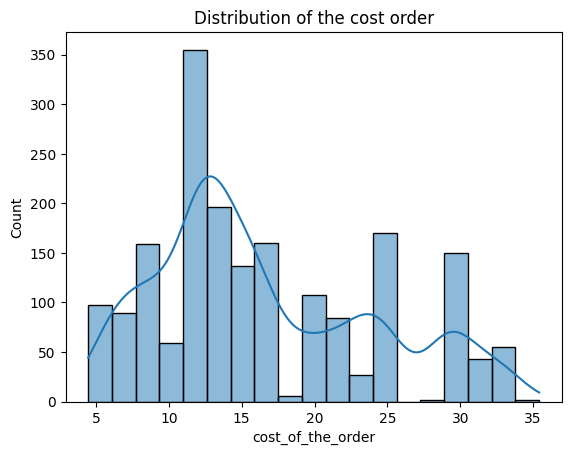%0A)

## Observation on Cost_of_the_order<a href="#Observation-on-Cost_of_the_order" class="anchor-link">¶</a>

1.  we can see that the tail for the graoh extended to right we can say
    that he graph is Right skewed.
2.  Most of the orders are on the lowest price range with very less
    orders with high cost

In \[11\]:

    sns.boxplot(df['cost_of_the_order'])
    plt.title('Boxplot of the cost order')
    plt.show()

![No description has been provided for this
image](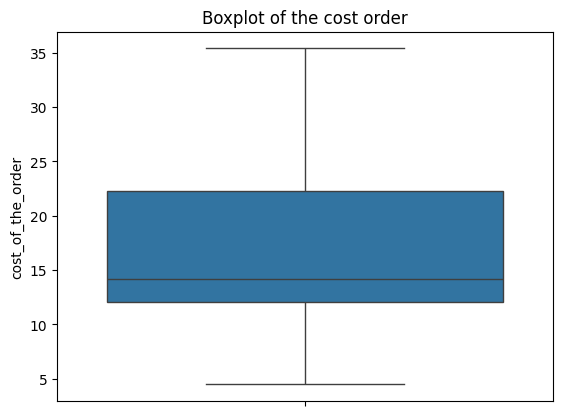%0A)

1.  By seeing the box plot we can say there are no outliers in the
    cost_of_the_order
2.  The median is near to x-axis and mean is slightly higher than median
    so we can say that the spread of this column is Right Skewed.

In \[12\]:

    sns.histplot(df['food_preparation_time'],kde=True)
    plt.title('Distribution of the food_preparation_time')
    plt.show()

![No description has been provided for this
image](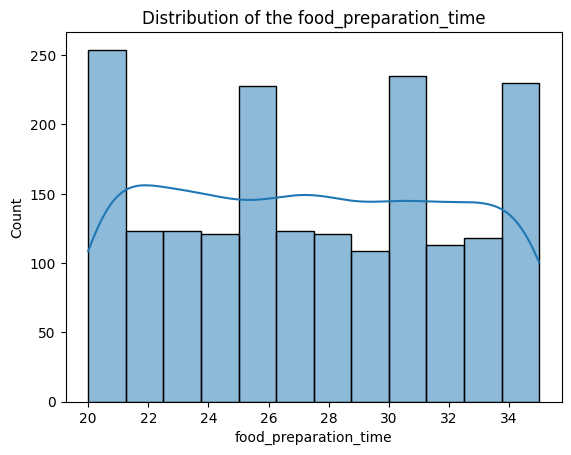%0A)

1.  The column food_preparation_time ,graph is symmetrically
    distributed.
2.  It says that there is similar amount of time for maximum of the food
    preparation process.

In \[13\]:

    sns.boxplot(x=df['food_preparation_time'])
    plt.title('Boxplot for food_preparation_time')
    plt.show()

![No description has been provided for this
image](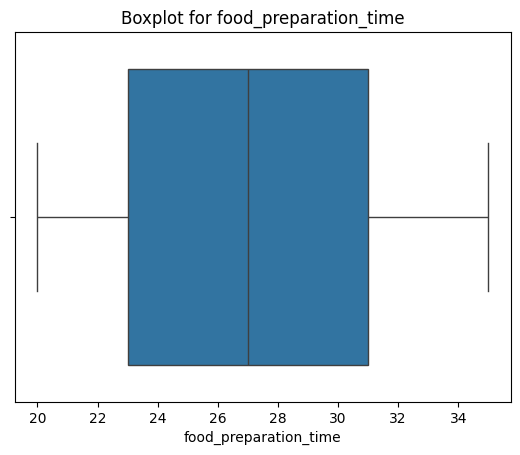%0A)

1.  There are no data points outside the whiskers, which means no
    outliers in this food_preparation_time.

In \[14\]:

    sns.histplot(df['delivery_time'], kde=True)
    plt.title('Distribution of Delivery Time')
    plt.show()

![No description has been provided for this
image](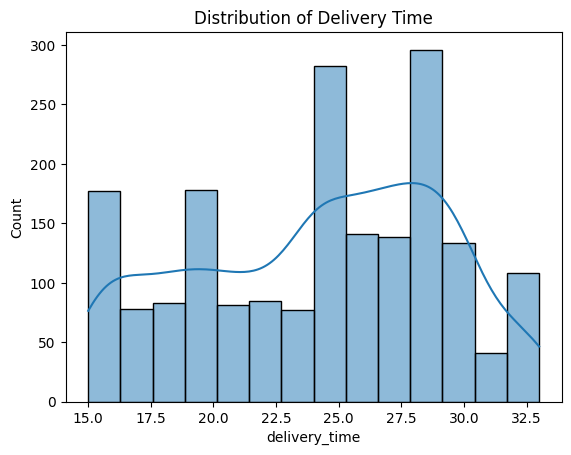%0A)

1.  Distribution is slightly left-skewed (lower times more frequent).
2.  Most of deliveries are within 20 to 28 minutes.

In \[15\]:

    sns.boxplot(x=df['delivery_time'])
    plt.title('Boxplot of Delivery Time')
    plt.show()

![No description has been provided for this
image](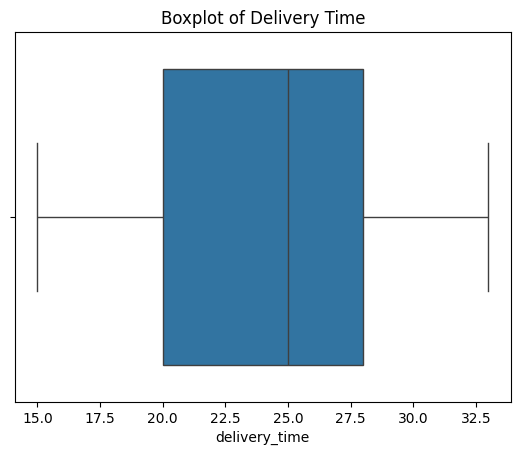%0A)

1.  There are no fast or slow deliveries, which indicates stability.

2.  The delivery service is likely reliable, completing most deliveries
    in 20-28 minutes.

In \[16\]:

    sns.scatterplot(data=df, x='food_preparation_time', y='cost_of_the_order' )
    plt.title('Order Cost vs Food Preparation Time')
    plt.show()

![No description has been provided for this
image](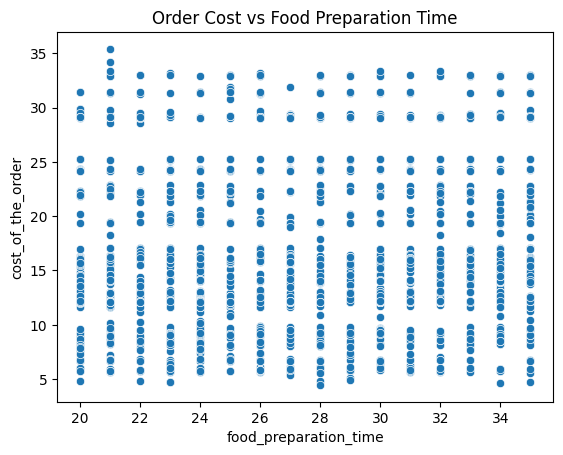%0A)

1.  The cost of a food order is not influenced by the preparation time.
    beacuse we can see the data points are evenly distributed all over
    the graph.

2.  Even the Food items priced differently it is taking take similar
    time to prepare.

3.  30 dollar meal and a \$10 meal both take approximately 25 minutes to
    prepare.

4.  The pricing may depend more on ingredients, brand, combo items,
    rather than complexity or duration.

In \[17\]:

    sns.scatterplot(data=df,x='delivery_time', y='cost_of_the_order' )
    plt.title('Order Cost vs Delivery Time')
    plt.show()

![No description has been provided for this
image](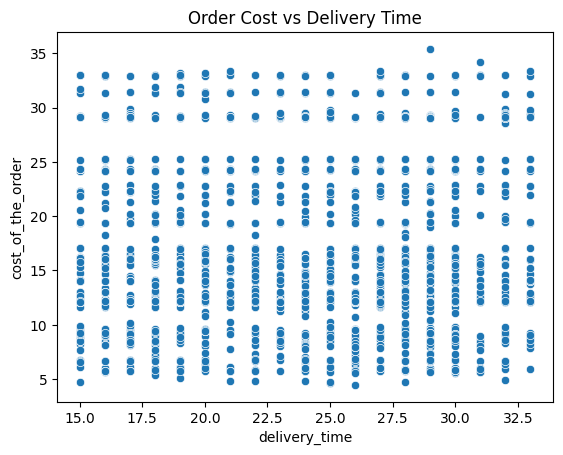%0A)

1.  The cost of an order does not have any impact on delivery time.

2.  Expensive orders are not prioritized, and small orders does not face
    delays either.

3.  There is no strong relationship between delivery time and cost of
    the order.So we can say uniform delivery policy, which is good for
    customer fairness.

In \[18\]:

    corr = df[['cost_of_the_order', 'food_preparation_time', 'delivery_time']].corr()
    sns.heatmap(corr, annot=True, cmap='Blues')
    plt.title("Correlation Matrix")
    plt.show()

![No description has been provided for this
image](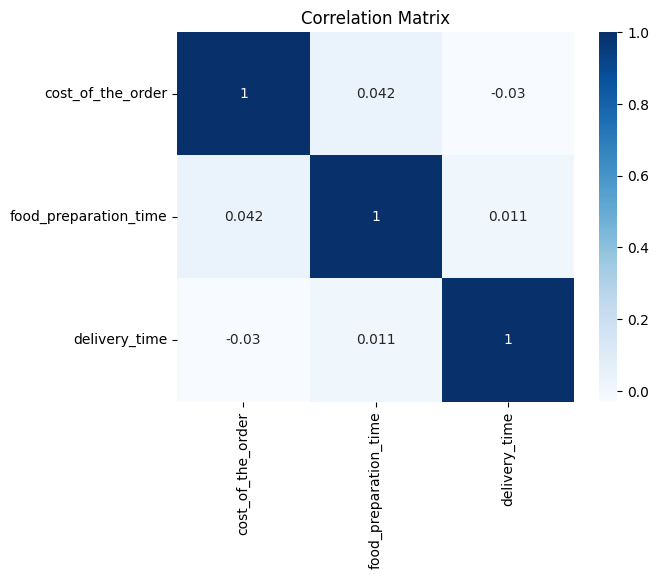%0A)

1.  cost_of_the_order & food_preparation_time has 0.042and has Very weak
    positive connection
2.  cost_of_the_order & delivery_time has -0.03 and Very weak negative
    connection
3.  food_preparation_time & delivery_time has 0.011 and has Almost no
    connection
4.  No strong linear relationships between any pair of variables.
5.  All values are between -0.03 to 0.04, which is negligible, almost
    equal to zero
6.  The cost of an order is independent of how long it takes to prepare
    or deliver, it suggets that pricing is not affected by operational
    timing factors

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? \[1 mark\]<a
href="#Question-7:-Which-are-the-top-5-restaurants-in-terms-of-the-number-of-orders-received?-%5B1-mark%5D"
class="anchor-link">¶</a>

In \[19\]:

    top_restraunts = df['restaurant_name'].value_counts().head(5)
    top_restraunts

Out\[19\]:

|                           | count |
|---------------------------|-------|
| restaurant_name           |       |
| Shake Shack               | 219   |
| The Meatball Shop         | 132   |
| Blue Ribbon Sushi         | 119   |
| Blue Ribbon Fried Chicken | 96    |
| Parm                      | 68    |

  
**dtype:** int64

#### Observations:<a href="#Observations:" class="anchor-link">¶</a>

1.  we can see that the shake shack restraunt has highest number of
    orders received in the weekends. This suggest that people prefer to
    drink juices and thick shakes on weekends
2.  The Meatball Shop follows the Shake Shack showing strong demand on
    weekends,possibly for its casual diding and shareable meni items
3.  Blue Ribbon Shushi is in the 3rd place reflecting high intrest
    japanese cuisine
4.  Blue Ribbon Fried chicken suggesting consistent popularity likely
    driven by fast food
5.  Parm with 68 orders in the top 5 indication steady intrest in
    Italian-American food

### **Question 8**: Which is the most popular cuisine on weekends? \[1 mark\]<a
href="#Question-8:-Which-is-the-most-popular-cuisine-on-weekends?-%5B1-mark%5D"
class="anchor-link">¶</a>

In \[20\]:

    weekend_orders = df[df['day_of_the_week'] == 'Weekend']

    popular_cuisine_weekend = weekend_orders['cuisine_type'].value_counts().idxmax()
    cuisine_counts_weekend = weekend_orders['cuisine_type'].value_counts()

    print("Cuisine-wise order count on weekends:")
    print(cuisine_counts_weekend)

    print(f"The most popular cuisine on the weekend is: {popular_cuisine_weekend}")

    Cuisine-wise order count on weekends:
    cuisine_type
    American          415
    Japanese          335
    Italian           207
    Chinese           163
    Mexican            53
    Indian             49
    Middle Eastern     32
    Mediterranean      32
    Thai               15
    French             13
    Korean             11
    Southern           11
    Spanish            11
    Vietnamese          4
    Name: count, dtype: int64
    The most popular cuisine on the weekend is: American

#### Observations:<a href="#Observations:" class="anchor-link">¶</a>

1.  American cuisine is most popular on weekends with 415 orders this
    suggest a strong preference in local or comfort food
2.  Japanese cuisine ranks 2nd from the above question observation we
    can see people are intrested in sushi or quck meal bites
3.  Italian and Chinese cuisines showin that they remain consistent
    favorites amoun customers
4.  Mexican and Indian cuisines have moderate demand on weekends suggets
    most of the immigrants showing intrest in exploring more cusines
5.  Cuisines like Middle eastren ,Mediterranean,Southeren,spanish and
    Vietnamese have relatively lower order indicating less frequent
    demand
6.  Vietnamese cusine has the least number of weekend order suggestig
    limited popularity or availability

### **Question 9**: What percentage of the orders cost more than 20 dollars? \[2 marks\]<a
href="#Question-9:-What-percentage-of-the-orders-cost-more-than-20-dollars?-%5B2-marks%5D"
class="anchor-link">¶</a>

In \[21\]:

    # Write the code here
    high_cost_orders = df[df['cost_of_the_order'] > 20]
    total_orders = len(df)
    high_cost_percentage = (len(high_cost_orders) / total_orders) * 100
    print(f"Percentage of orders costing more than $20: {high_cost_percentage:.2f}%")

    Percentage of orders costing more than $20: 29.24%

#### Observations:<a href="#Observations:" class="anchor-link">¶</a>

1.  29.24% of the total orders have a cost greater than 20dollars
    indicating that nearly 1 in 3 customers chosing higher values meals.
2.  Some customers are willing to spend more ,possibly for premium
    cusine,larger portions,or multiple items.
3.  foodHub can consider promoting combo deals or premium offerings to
    taret this customer segment more effectively

### **Question 10**: What is the mean order delivery time? \[1 mark\]<a
href="#Question-10:-What-is-the-mean-order-delivery-time?-%5B1-mark%5D"
class="anchor-link">¶</a>

In \[22\]:

    # Write the code here
    mean_delivery_time = df['delivery_time'].mean()
    print(f"Mean order delivery time: {mean_delivery_time:.2f} minutes")

    Mean order delivery time: 24.16 minutes

#### Observations:<a href="#Observations:" class="anchor-link">¶</a>

1.  The average delivery time accross all the orders is 24.16
    min,indicating that on aberage FoodHub delivers food within
    approximately 25 min after pickup
2.  we can say average of 25min in a busy city like Newyork is a
    reasonable time.
3.  However ,if the customer satisfacrion is top priority,eforts could
    be made further to reduce delivery timings.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. \[1 mark\]<a
href="#Question-11:-The-company-has-decided-to-give-20%25-discount-vouchers-to-the-top-3-most-frequent-customers.-Find-the-IDs-of-these-customers-and-the-number-of-orders-they-placed.-%5B1-mark%5D"
class="anchor-link">¶</a>

In \[23\]:

    # Write the code here
    top_customers = df['customer_id'].value_counts().head(3)
    print("Top 3 most frequent customers:")
    print(top_customers)

    Top 3 most frequent customers:
    customer_id
    52832    13
    47440    10
    83287     9
    Name: count, dtype: int64

#### Observations:<a href="#Observations:" class="anchor-link">¶</a>

1.  Customer with id 52832 is the most frequent customer placing 13
    orders making the top priority for the reward
2.  Rewarding the frequent customers can help customer retention and
    encourae continued use of the FoodHub platform.

### Multivariate Analysis<a href="#Multivariate-Analysis" class="anchor-link">¶</a>

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) \[10 marks\]<a
href="#Question-12:-Perform-a-multivariate-analysis-to-explore-relationships-between-the-important-variables-in-the-dataset.-(It-is-a-good-idea-to-explore-relations-between-numerical-variables-as-well-as-relations-between-numerical-and-categorical-variables)-%5B10-marks%5D"
class="anchor-link">¶</a>

In \[24\]:

    # Write the code here
    numerical_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
    corr_matrix = df[numerical_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='Blues')
    plt.title("Correlation Matrix")
    plt.show()

![No description has been provided for this
image](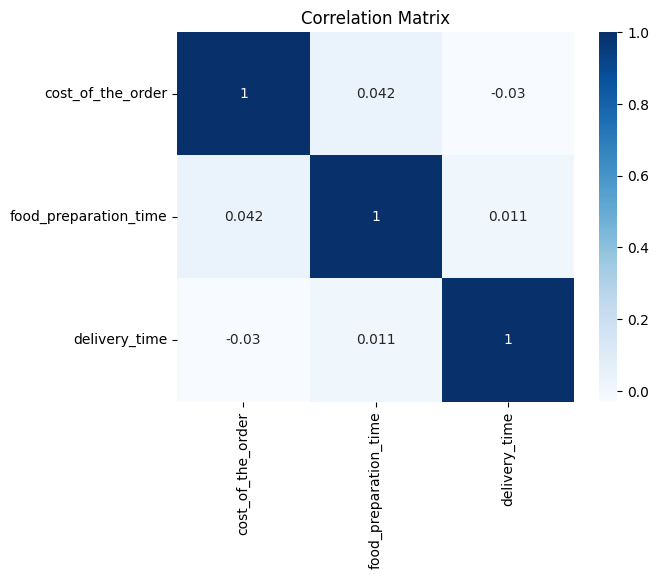%0A)

### Cost of the Order vs Food Preparation Time:<a href="#Cost-of-the-Order-vs-Food-Preparation-Time:"
class="anchor-link">¶</a>

1.  Correlation: 0.042

-        This indicates weak positive relationship, suggesting that as the cost of order increases, food preparation time slightly increases, but the effect is minimal.

### Cost of the Order vs Delivery Time:<a href="#Cost-of-the-Order-vs-Delivery-Time:" class="anchor-link">¶</a>

1.  Correlation: -0.03

-   This shows weak negative relationship, implying that higher-cost
    orders might be delivered slightly faster, though the connection is
    negligible.

### Food Preparation Time vs Delivery Time:<a href="#Food-Preparation-Time-vs-Delivery-Time:"
class="anchor-link">¶</a>

1.  Correlation: 0.011 This is an extremely weak positive connection,
    indicating almost no relationship between preparation time and
    delivery time.

### Self-connections:<a href="#Self-connections:" class="anchor-link">¶</a>

1.  Each variable has a perfect connection of 1 with itself, which is
    expected in any connection matrix.

In \[25\]:

    sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
    plt.title('Delivery Time by Day of the Week')
    plt.xticks(rotation=45)
    plt.show()

![No description has been provided for this
image](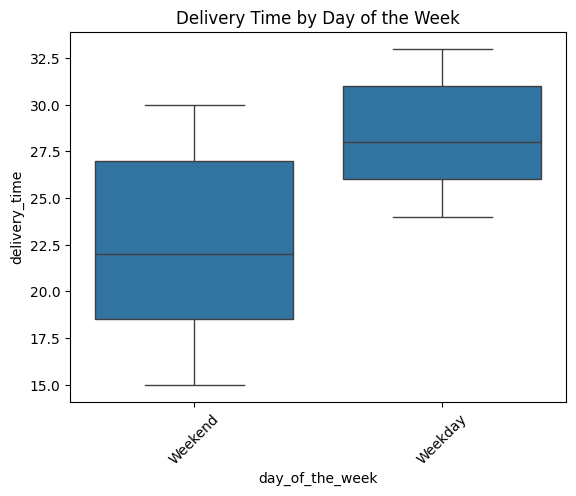%0A)

### Lower Delivery Times on Weekends:<a href="#Lower-Delivery-Times-on-Weekends:" class="anchor-link">¶</a>

1.  Deliveries tend to be faster on weekends, with a median delivery
    time of around 22.5 minutes, compared to 28 minutes on weekdays.

### Wider Spread on Weekends:<a href="#Wider-Spread-on-Weekends:" class="anchor-link">¶</a>

1.  The interquartile range (IQR) is wider for weekends, indicating more
    variability in delivery times.

### No Outliers:<a href="#No-Outliers:" class="anchor-link">¶</a>

1.  The data does not show any significant outliers in either category.

### Consistent Weekday Delays:<a href="#Consistent-Weekday-Delays:" class="anchor-link">¶</a>

1.  Weekday deliveries are generally slower and more consistent, with
    delivery times ranging from 22.5 to 32.5 minutes, while weekend
    deliveries range from 15 to 30 minutes.

In \[26\]:

    plt.figure(figsize=(12,6))
    sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=df)
    plt.title('Cost of orders by cuisine type')
    plt.xticks(rotation=45)
    plt.show()

![No description has been provided for this
image](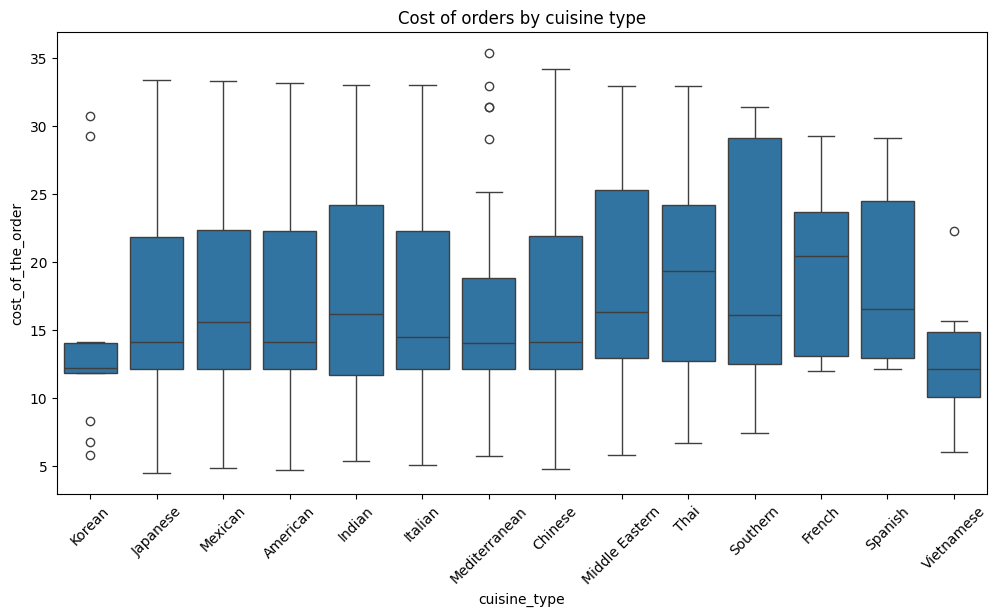%0A)

### Cuisine Variety:<a href="#Cuisine-Variety:" class="anchor-link">¶</a>

-   The chart compares order costs across multiple cuisine types
    including Korean, Japanese, Mexican, American, Italian,
    Mediterranean, Chinese, Middle Eastern, Thai, Southern, French,
    Spanish, and Vietnamese.

### Cost Distribution:<a href="#Cost-Distribution:" class="anchor-link">¶</a>

-   Each cuisine type has a distinct spread of order costs, shown
    through box plots with median lines and whiskers.

### Median Cost Differences:<a href="#Median-Cost-Differences:" class="anchor-link">¶</a>

-   Some cuisines (e.g., French, Japanese) appear to have higher median
    order costs compared to others (e.g., Mexican, Southern).

### Outliers Present:<a href="#Outliers-Present:" class="anchor-link">¶</a>

-   Several cuisines show outliers, represented by small circles,
    indicating unusually high or low order costs outside the typical
    range.

### Variation in Spread:<a href="#Variation-in-Spread:" class="anchor-link">¶</a>

-   The spread (interquartile range) varies by cuisine, suggesting
    differences in pricing consistency. For example, cuisines like
    Mediterranean or French may have wider spreads, indicating more
    variability in order costs.

In \[27\]:

    plt.figure(figsize=(12,6))
    sns.scatterplot(x='cost_of_the_order', y='rating', data=df,hue='cuisine_type')
    plt.title('Cost of orders by rating')
    plt.show()

![No description has been provided for this
image](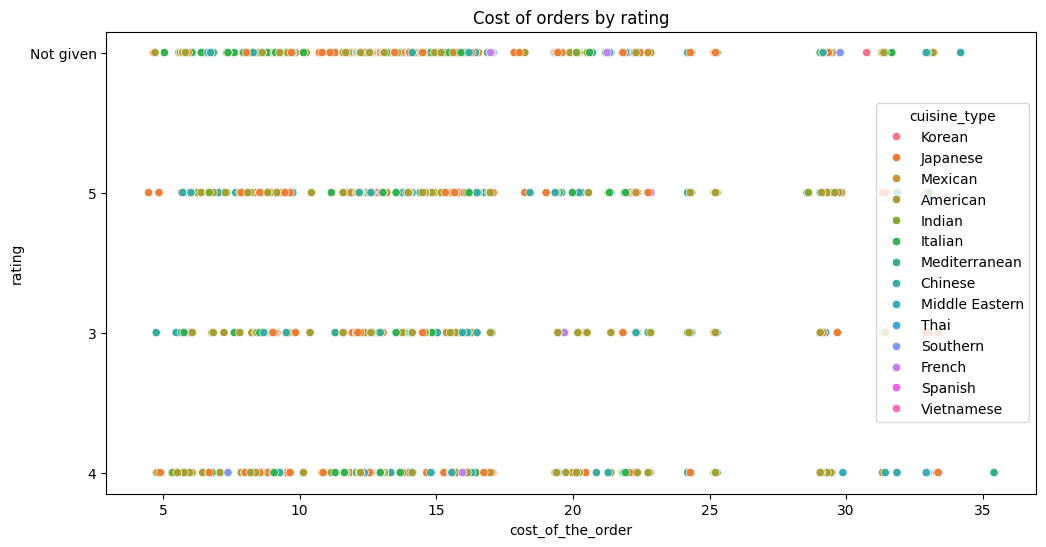%0A)

### Distribution of Ratings:<a href="#Distribution-of-Ratings:" class="anchor-link">¶</a>

Ratings are mostly concentrated around 3, 4, and 5, with a separate
category for "Not given". Orders with rating 5 tend to span a wide range
of costs, including higher-cost orders. Rating 3 and 4 orders are more
evenly distributed across the cost spectrum.

### Cost vs Rating Trends:<a href="#Cost-vs-Rating-Trends:" class="anchor-link">¶</a>

There is no clear linear trend between cost and rating; high-cost orders
are present across all rating levels. Some low-cost orders also receive
high ratings, indicating that cost does not necessarily determine
customer satisfaction.

### Cuisine-Specific Patterns:<a href="#Cuisine-Specific-Patterns:" class="anchor-link">¶</a>

Certain cuisines (e.g., French, Japanese, Mediterranean) appear more
frequently in the higher cost range. Others (e.g., Mexican, Southern,
Indian) are more common in the lower to mid-cost range. The diversity of
cuisines across ratings suggests that customer preferences vary widely
and are not solely cost-driven.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. \[3 marks\]<a
href="#Question-13:-The-company-wants-to-provide-a-promotional-offer-in-the-advertisement-of-the-restaurants.-The-condition-to-get-the-offer-is-that-the-restaurants-must-have-a-rating-count-of-more-than-50-and-the-average-rating-should-be-greater-than-4.-Find-the-restaurants-fulfilling-the-criteria-to-get-the-promotional-offer.-%5B3-marks%5D"
class="anchor-link">¶</a>

In \[28\]:

    df_rating = df.copy()
    df_rating['rating'] = pd.to_numeric(df_rating['rating'], errors='coerce')
    df_rating.dropna(subset=['rating'], inplace=True)
    restaurant_stats = df_rating.groupby('restaurant_name')['rating'].agg(['count', 'mean'])
    eligible_restaurants = restaurant_stats[(restaurant_stats['count'] > 50) & (restaurant_stats['mean'] > 4)]
    print("Restaurants eligible for the promotional offer:")
    print(eligible_restaurants)

    Restaurants eligible for the promotional offer:
                               count      mean
    restaurant_name                           
    Blue Ribbon Fried Chicken     64  4.328125
    Blue Ribbon Sushi             73  4.219178
    Shake Shack                  133  4.278195
    The Meatball Shop             84  4.511905

1.  Here are the listed restaurants which qualify for the promotional
    offer, indicating a strong overall performance in customer
    satisfaction and engagement.
2.  The Meatball Shop stands out with the highest average rating of
    4.51, suggesting exceptional customer feedback.
3.  Shake Shack has the highest number of ratings (133), reflecting its
    wide customer base and popularity.
4.  Both Blue Ribbon locations (Fried Chicken and Sushi) meet the
    criteria, showcasing consistent quality across different cuisines
    under the same brand.

#### Observations:<a href="#Observations:" class="anchor-link">¶</a>

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. \[3 marks\]<a
href="#Question-14:-The-company-charges-the-restaurant-25%25-on-the-orders-having-cost-greater-than-20-dollars-and-15%25-on-the-orders-having-cost-greater-than-5-dollars.-Find-the-net-revenue-generated-by-the-company-across-all-orders.-%5B3-marks%5D"
class="anchor-link">¶</a>

In \[29\]:

    # Write the code here
    def compute_revenue(order_cost):
        if order_cost > 20:
            return order_cost * 0.25
        elif order_cost > 5:
            return order_cost * 0.15
        else:
            return 0
    df['company_revenue'] = df['cost_of_the_order'].apply(compute_revenue)
    total_revenue = df['company_revenue'].sum()
    print(f"The total revenue earned by the company is: ${total_revenue:.2f}")

    The total revenue earned by the company is: $6166.30

#### Observations:<a href="#Observations:" class="anchor-link">¶</a>

1.  The company uses a tiered commission structure, which allows it to
    earn more from higher-value orders while still capturing revenue
    from mid-range orders.
2.  A total revenue of 6166.30 dollars indicates that the company has
    successfully monetized its platform through this commission model.
3.  Given the higher commission rate for orders above 20 dollars, a
    significant portion of the revenue likely comes from premium or bulk
    orders, suggesting strong customer spending behavior.
4.  The inclusion of a 15% commission for orders above \$5 ensures that
    even smaller transactions contribute to the overall revenue,
    maintaining a steady income flow.
5.  This model is scalable — as the number of orders increases,
    especially in the higher price bracket, the company’s revenue will
    grow proportionally.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) \[2 marks\]<a
href="#Question-15:-The-company-wants-to-analyze-the-total-time-required-to-deliver-the-food.-What-percentage-of-orders-take-more-than-60-minutes-to-get-delivered-from-the-time-the-order-is-placed?-(The-food-has-to-be-prepared-and-then-delivered.)-%5B2-marks%5D"
class="anchor-link">¶</a>

In \[30\]:

    df['total_delivery_time'] = df['food_preparation_time'] + df['delivery_time']
    delayed_orders = df[df['total_delivery_time'] > 60]
    num_delayed = len(delayed_orders)
    total_orders = len(df)
    percentage_delayed = (num_delayed / total_orders) * 100
    print(f"Percentage of orders that took more than 60 minutes: {percentage_delayed:.2f}%")

    Percentage of orders that took more than 60 minutes: 10.54%

#### Observations:<a href="#Observations:" class="anchor-link">¶</a>

-   There are more that 10.54% of orders which took more than 1 hour
-   The company FoodHub should know the correct reasons for the delayed
    orders and oversome it to get increase their customers and sales

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? \[2 marks\]<a
href="#Question-16:-The-company-wants-to-analyze-the-delivery-time-of-the-orders-on-weekdays-and-weekends.-How-does-the-mean-delivery-time-vary-during-weekdays-and-weekends?-%5B2-marks%5D"
class="anchor-link">¶</a>

In \[31\]:

    mean_delivery_times = df.groupby('day_of_the_week')['delivery_time'].mean()
    print("Mean Delivery Time:")
    print(mean_delivery_times)

    Mean Delivery Time:
    day_of_the_week
    Weekday    28.340037
    Weekend    22.470022
    Name: delivery_time, dtype: float64

#### Observations:<a href="#Observations:" class="anchor-link">¶</a>

1.  The company's analysis of delivery times reveals a clear difference
    between weekdays and weekends:

-   Weekday Mean Delivery Time: 28.34 minutes
-   Weekend Mean Delivery Time: 22.47 minutes

1.  Delivery is faster on weekends by approximately 5.87 minutes.
2.  This suggests that operational efficiency or external factors (like
    reduced traffic or fewer orders) contribute to quicker deliveries
    during weekends.
3.  The company may consider investigating weekday delays further to
    improve overall delivery performance.

### Conclusion and Recommendations<a href="#Conclusion-and-Recommendations" class="anchor-link">¶</a>

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) \[6 marks\]<a
href="#Question-17:-What-are-your-conclusions-from-the-analysis?-What-recommendations-would-you-like-to-share-to-help-improve-the-business?-(You-can-use-cuisine-type-and-feedback-ratings-to-drive-your-business-recommendations.)-%5B6-marks%5D"
class="anchor-link">¶</a>

### Conclusions:<a href="#Conclusions:" class="anchor-link">¶</a>

1.  People mostly prefer familiar and comforting meals when ordering
    food on weekends. These types of meals are ordered far more often
    than others.
2.  A few food outlets consistently receive a high number of orders,
    showing they are favorites among customers.
3.  Nearly 3 out of 10 food orders are on the higher-priced side, which
    means there's a good number of customers willing to spend more for
    quality or larger meals.
4.  On average, it takes around 24 minutes to deliver an order after
    it's picked up, which is fairly reasonable but can still be made
    faster.
5.  Some orders take more than an hour to reach the customer from the
    time they were placed. This points to possible delays in preparation
    or delivery.
6.  Deliveries generally take longer on weekends than weekdays, likely
    because more people order food during their free time.
7.  A few customers have ordered food many times, showing strong loyalty
    and satisfaction with the service.
8.  When food takes too long to prepare or deliver, customers tend to
    give lower ratings, highlighting the importance of speed in keeping
    them happy.

### Recommendations:<a href="#Recommendations:" class="anchor-link">¶</a>

1.  Improve weekend operations. Since delays are more common on
    weekends, consider increasing delivery staff or adjusting time slots
    to handle the higher demand.
2.  Promote popular meal types. Highlight the dishes people love most
    during weekends to increase engagement and sales.
3.  Reward loyal users. Offer special deals or discounts to customers
    who order frequently to keep them coming back.
4.  Reduce delays. Work with kitchen teams and delivery staff to speed
    up service, especially for those orders that often take too long.
5.  Encourage larger orders. Since many customers are willing to spend
    more, consider offering discounts or free delivery for orders above
    a certain amount.
6.  Use customer feedback wisely. Highlight highly rated food options to
    help new users choose well and boost confidence in ordering.
7.  Feature trusted food providers. Give more visibility to the outlets
    with consistently good service and reviews to raise overall
    satisfaction.